In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


In [3]:
# --- Raw input rows (from your cleaned lists) ---
accurate_rows = [
 (331.6,5.2,25.000),(332.4,5.8,25.000),(332.3,5.6,25.000),(332.1,5.4,25.000),
 (332.9,5.1,25.000),(332.3,6.2,25.000),(332.7,6.4,25.000),(331.9,6.1,25.000),
 (331.8,6.3,25.000),(332.6,6.0,25.000),(332.9,6.1,25.000),(332.3,6.9,25.000),
 (332.6,6.7,25.000),(333.0,6.2,25.000),(332.4,5.8,25.000),(332.8,7.1,25.000),
 (332.8,6.9,25.000),(331.4,6.2,25.000),(331.6,6.4,25.000),(332.8,7.2,25.000),
 (332.2,7.9,25.000),(332.5,7.8,25.000),(332.4,7.4,25.000),(332.7,7.6,25.000),
 (332.9,7.7,25.000),(332.6,6.9,25.000),(332.9,7.5,25.000),(332.5,8.0,25.000),
 (332.8,8.2,25.000),(332.4,8.1,25.000),(332.9,7.9,25.000)
]

under_rows = [
 (313.4,9.2,25.000),(310.8,9.4,25.000),(304.2,6.3,23.000),(298.6,10.2,23.000),
 (299.1,11.8,23.000),(284.7,9.2,23.000),(304.1,7.1,23.000),(321.0,6.6,18.000),
 (323.0,12.8,12.912),(310.1,14.3,8.010),(299.8,21.2,5.901),(296.7,16.3,5.901),
 (301.1,18.4,5.901)
]

over_rows = [
 (339.6,16.2,5.901),(401.2,12.1,18.000),(337.1,12.4,18.000),(339.8,11.9,18.000),
 (338.8,11.8,23.000),(336.9,8.1,23.000),(336.8,8.2,3.210),(404.6,8.9,23.210),
 (411.1,16.2,15.210),(392.0,16.9,15.210),(390.1,16.4,15.210),(399.0,16.5,15.210),
 (401.2,17.1,14.000),(400.2,19.0,10.000),(410.2,21.4,9.161),(390.1,6.1,23.000),
 (401.0,6.9,23.000),(382.6,6.2,23.000),(371.1,6.6,23.000),(392.1,9.1,23.000),
 (421.0,6.8,23.000)
]


In [4]:
# --- Build DataFrame ---
cols = ["fill_level","temperature","production_speed","label"]
rows = []
for f,t,s in accurate_rows:
    rows.append([f,t,s,"normal"])
for f,t,s in under_rows:
    rows.append([f,t,s,"under"])
for f,t,s in over_rows:
    rows.append([f,t,s,"over"])

df = pd.DataFrame(rows, columns=cols)

In [5]:
# --- Ensure numeric types ---
df["fill_level"] = pd.to_numeric(df["fill_level"], errors="coerce")
df["temperature"] = pd.to_numeric(df["temperature"], errors="coerce")
df["production_speed"] = pd.to_numeric(df["production_speed"], errors="coerce")

In [6]:
# Drop any malformed rows (none expected)
df = df.dropna(subset=["fill_level","temperature","production_speed"]).reset_index(drop=True)

print("Original class counts:\n", df['label'].value_counts(), "\n")

Original class counts:
 label
normal    31
over      21
under     13
Name: count, dtype: int64 



In [7]:

# --- Augmentation: make classes balanced to N per class ---
TARGET_PER_CLASS = 100
rng = np.random.default_rng(2025)

augmented = []
for label in ["under","normal","over"]:
    subset = df[df['label']==label]
    current = len(subset)
    needed = max(0, TARGET_PER_CLASS - current)
    if needed==0:
        continue
    mu_fill = subset['fill_level'].mean()
    sigma_fill = subset['fill_level'].std() if subset['fill_level'].std()>0 else 1.0
    mu_temp = subset['temperature'].mean()
    sigma_temp = subset['temperature'].std() if subset['temperature'].std()>0 else 0.5
    mu_speed = subset['production_speed'].mean()
    sigma_speed = subset['production_speed'].std() if subset['production_speed'].std()>0 else 1.0
    # clipping ranges per class
    if label=="normal":
        low, high = 331.4, 333.0
    elif label=="under":
        low, high = 280.0, 320.0
    else:
        low, high = 336.0, 420.0
    for _ in range(needed):
        val_fill = float(np.clip(rng.normal(mu_fill, sigma_fill), low, high))
        val_temp = float(np.clip(rng.normal(mu_temp, sigma_temp), -10, 50))
        val_speed = float(np.clip(rng.normal(mu_speed, sigma_speed), 0.1, 200.0))
        augmented.append([val_fill, val_temp, val_speed, label])

df_aug = pd.DataFrame(augmented, columns=cols)
df_final = pd.concat([df, df_aug], ignore_index=True)
df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)


In [8]:
# --- Save CSV ---
out_file = Path("30cl_clean_augmented.csv")
df_final.to_csv(out_file, index=False)

In [9]:
# --- Print summary ---
print("Final class counts:\n", df_final['label'].value_counts(), "\n")
print("Saved cleaned + augmented CSV to:", out_file.resolve())
print("\nSample rows:\n", df_final.head(10))

Final class counts:
 label
normal    100
over      100
under     100
Name: count, dtype: int64 

Saved cleaned + augmented CSV to: /home/abraham/ml_project2/30cl_clean_augmented.csv

Sample rows:
    fill_level  temperature  production_speed   label
0  332.422125     7.360569         25.282952  normal
1  392.384849    12.738866         17.087465    over
2  332.808424     6.837234         25.576967  normal
3  332.600000     6.000000         25.000000  normal
4  385.328190    21.313787         10.665388    over
5  396.472814    13.153548         19.754324    over
6  332.642170     5.910678         25.375241  normal
7  280.732749    10.968009         23.263922   under
8  332.300000     6.200000         25.000000  normal
9  332.177219     8.228765         25.028121  normal


In [10]:
# Sanity checks (no data modification)
df_final.groupby("label").agg(
    min_fill=("fill_level", "min"),
    max_fill=("fill_level", "max"),
    mean_fill=("fill_level", "mean")
)


,min_fill,max_fill,mean_fill
label,,,
normal,331.4,333.0,332.456020
over,336.0,421.0,382.495787
under,280.0,323.0,303.253089


<Axes: title={'center': 'fill_level'}, xlabel='label'>

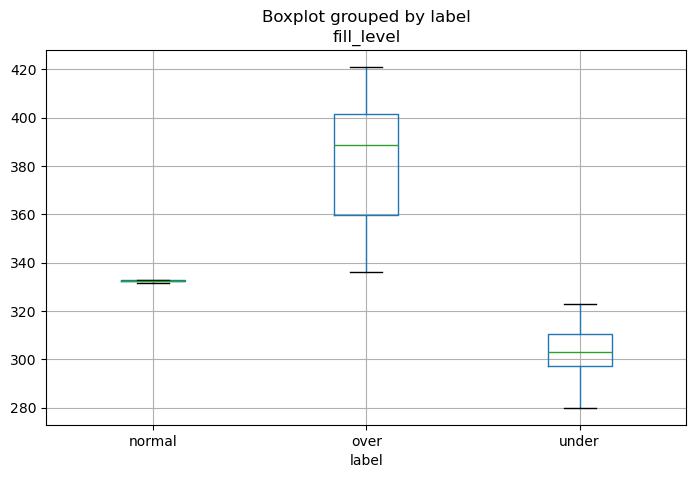

In [11]:
df_final.boxplot(column="fill_level", by="label", figsize=(8,5))


In [12]:
X = df_final[["fill_level", "temperature", "production_speed"]]
y = df_final["label"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [14]:
print("Training set class distribution:")
print(y_train.value_counts(), "\n")

print("Test set class distribution:")
print(y_test.value_counts())


Training set class distribution:
label
normal    80
over      80
under     80
Name: count, dtype: int64 

Test set class distribution:
label
normal    20
under     20
over      20
Name: count, dtype: int64


In [15]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)


In [16]:
rf_model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [17]:
y_pred_rf = rf_model.predict(X_test)


In [18]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 1.0


In [19]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:\n", cm_rf)

Confusion Matrix:
 [[20  0  0]
 [ 0 20  0]
 [ 0  0 20]]


In [20]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred_rf))

Classification Report:

              precision    recall  f1-score   support

      normal       1.00      1.00      1.00        20
        over       1.00      1.00      1.00        20
       under       1.00      1.00      1.00        20

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



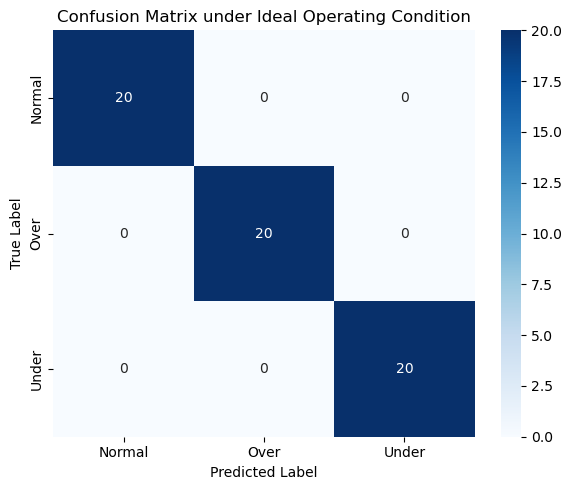

In [21]:
# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Over", "Under"],
    yticklabels=["Normal", "Over", "Under"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix under Ideal Operating Condition")
plt.tight_layout()
plt.show()


In [22]:
# Robustness with noice
X_test_noisy = X_test.copy() 


In [23]:
# Add Gaussian noise to fill_level
np.random.seed(42)

noise = np.random.normal(
    loc=0.0,
    scale=1.0,   # 1 ml standard deviation
    size=len(X_test_noisy)
)

X_test_noisy["fill_level"] = X_test_noisy["fill_level"] + noise


In [24]:
# Predict on noisy data
y_pred_rf_noisy = rf_model.predict(X_test_noisy)


In [25]:
# Evaluate performance under noise

print("Accuracy with noisy fill-level data:")
print(accuracy_score(y_test, y_pred_rf_noisy))

print("\nConfusion Matrix (Noisy Data):")
print(confusion_matrix(y_test, y_pred_rf_noisy))

print("\nClassification Report (Noisy Data):")
print(classification_report(y_test, y_pred_rf_noisy))


Accuracy with noisy fill-level data:
1.0

Confusion Matrix (Noisy Data):
[[20  0  0]
 [ 0 20  0]
 [ 0  0 20]]

Classification Report (Noisy Data):
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00        20
        over       1.00      1.00      1.00        20
       under       1.00      1.00      1.00        20

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



In [65]:
# Create a stressed test copy
X_test_stress = X_test.copy()


In [114]:
# Add strong Gaussian noise (σ = 5 ml)
np.random.seed(42)
stress_noise = np.random.normal(
    loc=0.0,
    scale=1.0,   # STRONG noise (stress condition)
    size=len(X_test_stress)
)

X_test_stress["fill_level"] = X_test_stress["fill_level"] + stress_noise


In [115]:
# Predict with Random Forest
y_pred_rf_stress = rf_model.predict(X_test_stress)


In [116]:
# Evaluate stressed performance
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy under strong noise stress (σ = 3 ml):")
print(accuracy_score(y_test, y_pred_rf_stress))

print("\nConfusion Matrix (Stress Test):")
print(confusion_matrix(y_test, y_pred_rf_stress))

print("\nClassification Report (Stress Test):")
print(classification_report(y_test, y_pred_rf_stress))


Accuracy under strong noise stress (σ = 3 ml):
0.8166666666666667

Confusion Matrix (Stress Test):
[[10  0 10]
 [ 0 20  0]
 [ 1  0 19]]

Classification Report (Stress Test):
              precision    recall  f1-score   support

      normal       0.91      0.50      0.65        20
        over       1.00      1.00      1.00        20
       under       0.66      0.95      0.78        20

    accuracy                           0.82        60
   macro avg       0.85      0.82      0.81        60
weighted avg       0.85      0.82      0.81        60



In [92]:
# Plot the confusion matrix (stress case)

# Import plotting utilities

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


In [93]:
# Compute confusion matrix (stress case)
cm_stress = confusion_matrix(y_test, y_pred_rf_stress)


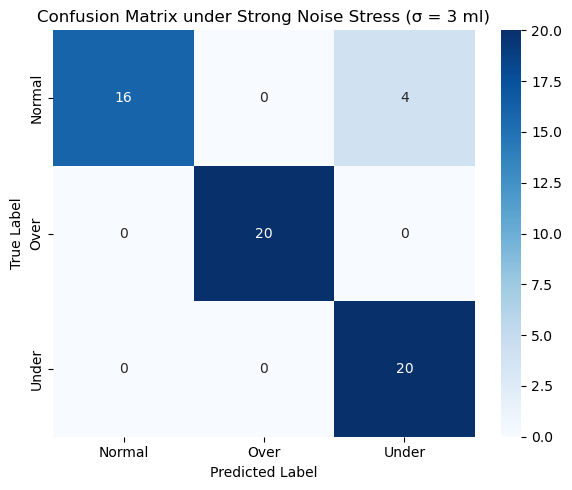

In [94]:
# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_stress,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Over", "Under"],
    yticklabels=["Normal", "Over", "Under"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix under Strong Noise Stress (σ = 3 ml)")
plt.tight_layout()
plt.show()


In [95]:
# Extract feature importance

import pandas as pd

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance


fill_level          0.558614
production_speed    0.236217
temperature         0.205170
dtype: float64

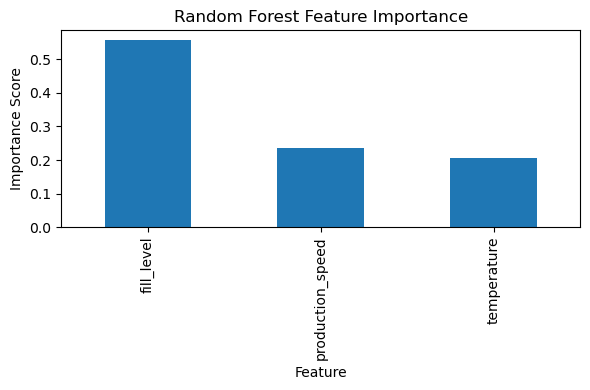

In [96]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
feature_importance.plot(kind="bar")

plt.ylabel("Importance Score")
plt.xlabel("Feature")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()


In [97]:
# Install & import XGBoost
from xgboost import XGBClassifier


In [98]:
# Encode labels
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

le.classes_


array(['normal', 'over', 'under'], dtype=object)

In [99]:
# Initialize XGBoost (safe baseline)

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softmax",
    num_class=3,
    random_state=42,
    eval_metric="mlogloss"
)


In [100]:
# Train XGBoost

xgb_model.fit(X_train, y_train_enc)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

In [101]:
# Predict & accuracy

from sklearn.metrics import accuracy_score

y_pred_xgb_enc = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test_enc, y_pred_xgb_enc)

print("XGBoost Accuracy:", xgb_accuracy)


XGBoost Accuracy: 1.0


In [102]:
# Classification report

y_pred_xgb = le.inverse_transform(y_pred_xgb_enc)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_xgb))


              precision    recall  f1-score   support

      normal       1.00      1.00      1.00        20
        over       1.00      1.00      1.00        20
       under       1.00      1.00      1.00        20

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



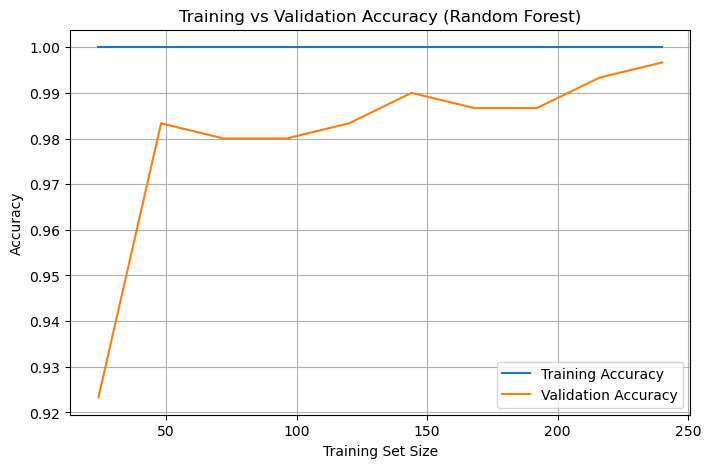

In [103]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    rf_model,
    X,
    y,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, label="Training Accuracy")
plt.plot(train_sizes, val_mean, label="Validation Accuracy")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy (Random Forest)")
plt.legend()
plt.grid(True)
plt.show()


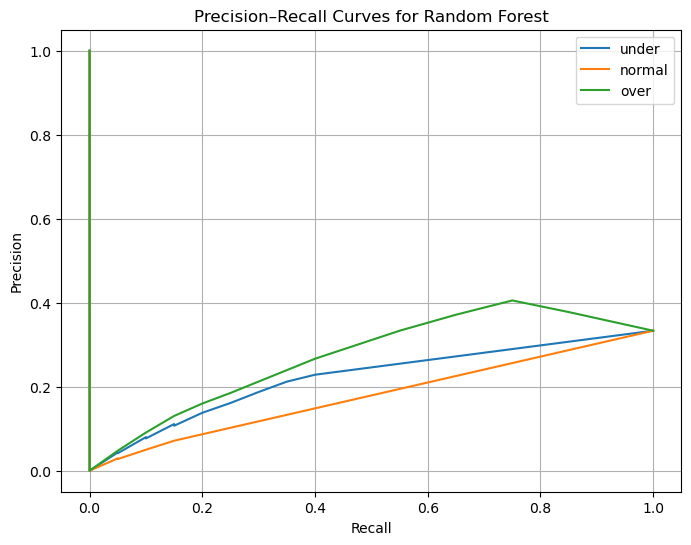

In [104]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve

y_test_bin = label_binarize(y_test, classes=["under", "normal", "over"])
y_score = rf_model.predict_proba(X_test)

plt.figure(figsize=(8,6))
for i, label in enumerate(["under", "normal", "over"]):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
    plt.plot(recall, precision, label=label)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves for Random Forest")
plt.legend()
plt.grid(True) 
plt.show()


In [105]:
# Expanded Robustness
# Temperature noise
X_temp_noisy = X_test.copy()
X_temp_noisy["temperature"] += np.random.normal(0, 1.0, size=len(X_test))


In [106]:
# Production speed noise
X_speed_noisy = X_test.copy()
X_speed_noisy["production_speed"] += np.random.normal(0, 1.0, size=len(X_test))


In [107]:
# Combined noise
X_combined = X_test.copy()
X_combined["fill_level"] += np.random.normal(0, 5, size=len(X_test))
X_combined["temperature"] += np.random.normal(0, 1, size=len(X_test))
X_combined["production_speed"] += np.random.normal(0, 1, size=len(X_test))


In [108]:
# Define a small helper function.  This keeps things clean and readable.
from sklearn.metrics import accuracy_score

def evaluate_accuracy(model, X_test_variant, y_test, label):
    y_pred = model.predict(X_test_variant)
    acc = accuracy_score(y_test, y_pred)
    print(f"{label} Accuracy: {acc:.3f}")
    return acc


In [109]:
# Evaluate each robustness scenario
# Clean baseline
acc_clean = evaluate_accuracy(rf_model, X_test, y_test, "Clean data")

# Temperature noise
acc_temp = evaluate_accuracy(rf_model, X_temp_noisy, y_test, "Temperature noise")

# Production speed noise
acc_speed = evaluate_accuracy(rf_model, X_speed_noisy, y_test, "Production speed noise")

# Combined noise
acc_combined = evaluate_accuracy(rf_model, X_combined, y_test, "Combined noise")


Clean data Accuracy: 1.000
Temperature noise Accuracy: 1.000
Production speed noise Accuracy: 1.000
Combined noise Accuracy: 0.967


In [110]:
# Put results into a table
import pandas as pd

robustness_table = pd.DataFrame({
    "Scenario": [
        "Clean data",
        "Temperature noise",
        "Production speed noise",
        "Combined noise"
    ],
    "Accuracy": [
        acc_clean,
        acc_temp,
        acc_speed,
        acc_combined
    ]
})

robustness_table


,Scenario,Accuracy
0,Clean data,1.000000
1,Temperature noise,1.000000
2,Production speed noise,1.000000
3,Combined noise,0.966667
